In [175]:
import warnings
import numpy as np
import pandas as pd
from scipy.fft import rfft, rfftfreq
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_ccf, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from pywt import cwt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from itertools import product
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

warnings.filterwarnings("ignore")

# Разведочный анализ данных (EDA)

## Загрузка датасета, исследование структуры, test-train split

In [2]:
df = pd.read_csv("./datasets/retail_sales_mock_data.csv", parse_dates=True, index_col="Date")
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

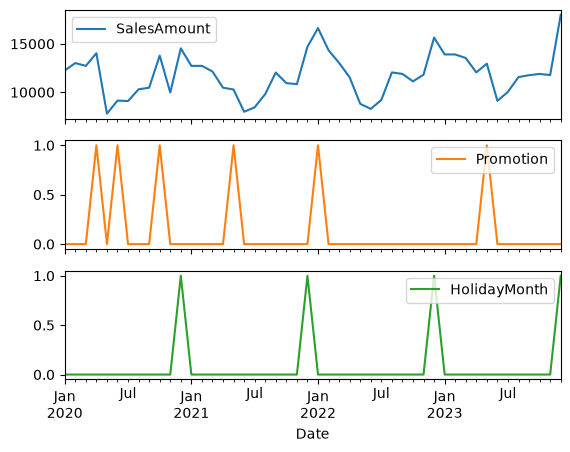

In [6]:
df.plot(subplots=True)

In [21]:
# из таблицы выше, что данные брались 1 раз в месяц
# проверим, присутствуют ли пропуски
months = (df.index.year - df.index.year[0]) * 12 + (df.index.month - df.index.month[0])
month_idx = df.index.year * 12 + df.index.month
print(np.max(np.diff(month_idx)))  # =1 - нет пропусков, >1 - есть пропуски

1


In [22]:
# сразу разбиваю train-test, чтобы избежать look-ahead bias в результате ручного анализа
# т.е. test часть не трогаю до момента проверки модели
full_len = len(df[:])
train_len = int(0.75 * full_len) # 75%
test_len = full_len - train_len # 25%

sales_full = df["SalesAmount"]
promotion_full = df["Promotion"]
holiday_full = df["HolidayMonth"]

sales_train = sales_full[:train_len]
promotion_train = promotion_full[:train_len]
holiday_train = holiday_full[:train_len]

sales_test = sales_full[-test_len:]
promotion_test = promotion_full[-test_len:]
holiday_test = holiday_full[-test_len:]

print(len(sales_full), len(sales_train), len(sales_test))

48 36 12


## Предварительный анализ данных

### Разные формы представления

[]

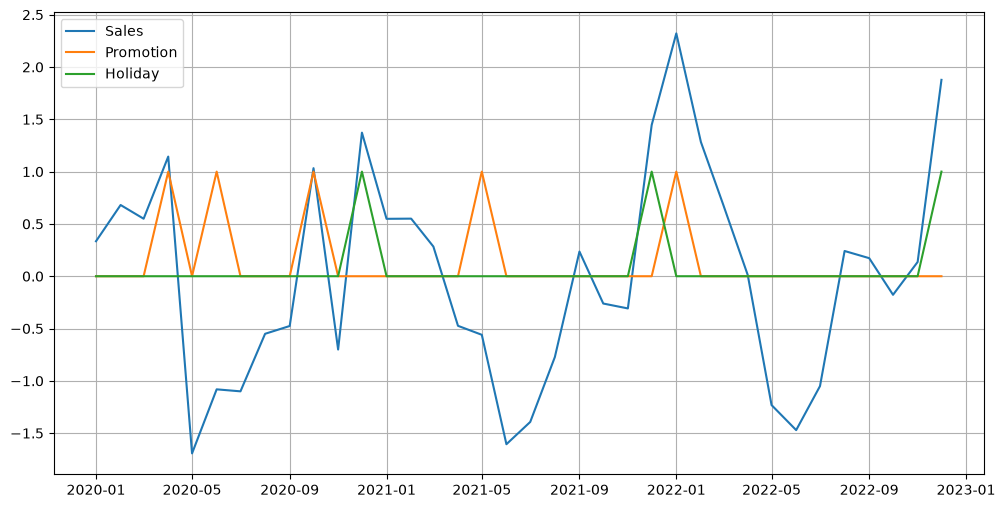

In [35]:
plt.figure(figsize=(12, 6))
plt.grid()
sales_norm = (sales_train - np.mean(sales_train)) / np.std(sales_train) # нормировка для удобства сравнения форм
plt.plot(sales_norm, label="Sales")
plt.plot(promotion_train, label="Promotion")
plt.plot(holiday_train, label="Holiday")
plt.legend()
plt.plot()

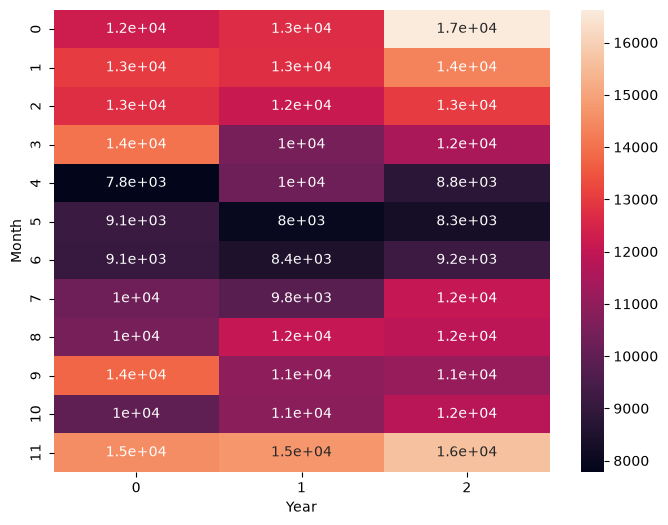

In [31]:
# построим тепловую карту год-месяц
sales_by_years = np.reshape(sales_train, shape=(3, 12)).T
plt.figure(figsize=(8, 6))
sns.heatmap(sales_by_years, annot=True)
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

### Корреляции

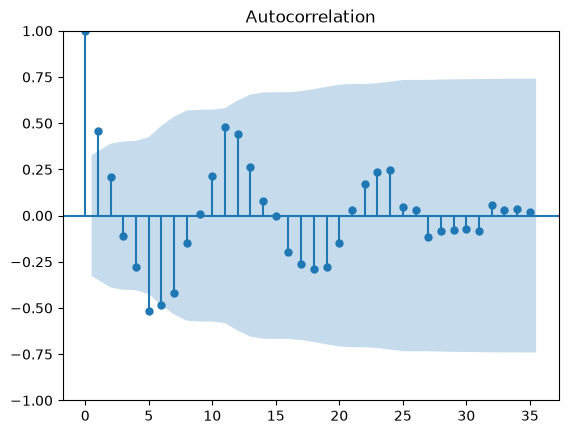

In [41]:
# автокорреляция
plot_acf(sales_train, lags=(len(sales_train) - 1))
plt.show()

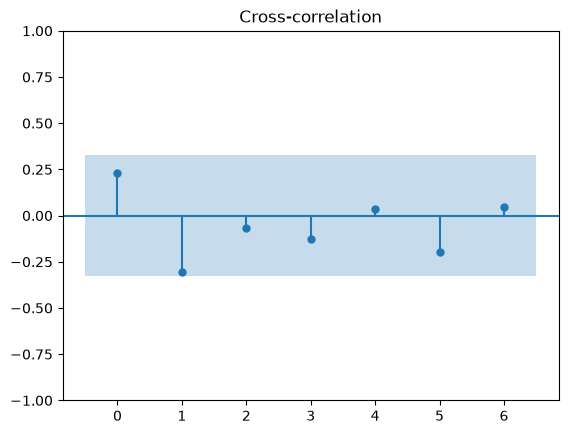

In [48]:
# кросс-корреляция рекламы и продаж
plot_ccf(sales_train, promotion_train, lags=6)  # из соображений здравого смысла ограничимся анализом на 6 месяцев
plt.show()

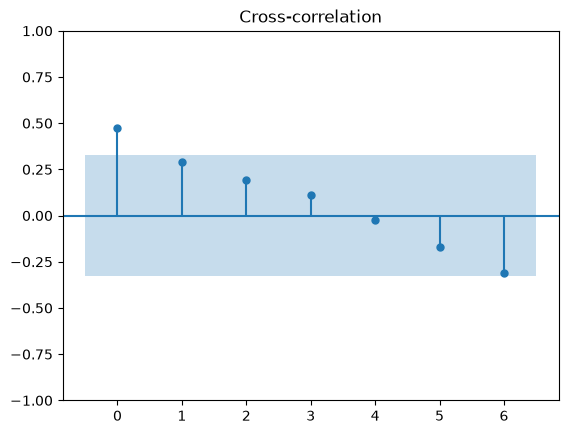

In [52]:
# кросс-корреляция рекламы и продаж
plot_ccf(sales_train, holiday_train, lags=6)
plt.show()

### Промежуточные результаты

1. Визуально легко заметить сезонность:
   - Форма, похожая на синусоиду
   - На тепловой карте строка 12 месяца показывает значения, заметно выше остальных
   - На тепловой карте строки за 5 и 6 месяца значительно отстают от остальных
2. Данное визульное наблюдение подтверждает автокорреляционной функцией - статистически значимые значения на лагах 2, 5, 6
3. Сезонность пиков совпадает с праздичными месяцами - значимая кросскорелляция на лаге 0
4. Рекалама не оказывает статистически значимого результата на продажи согласно кросскорелляциолнной функции

П.4 имеет важное значение для дальнейшей работы - данные о рекламе не будут больше рассматриваться, т.к. являются статистически незначимыми.

## Декомпозиции

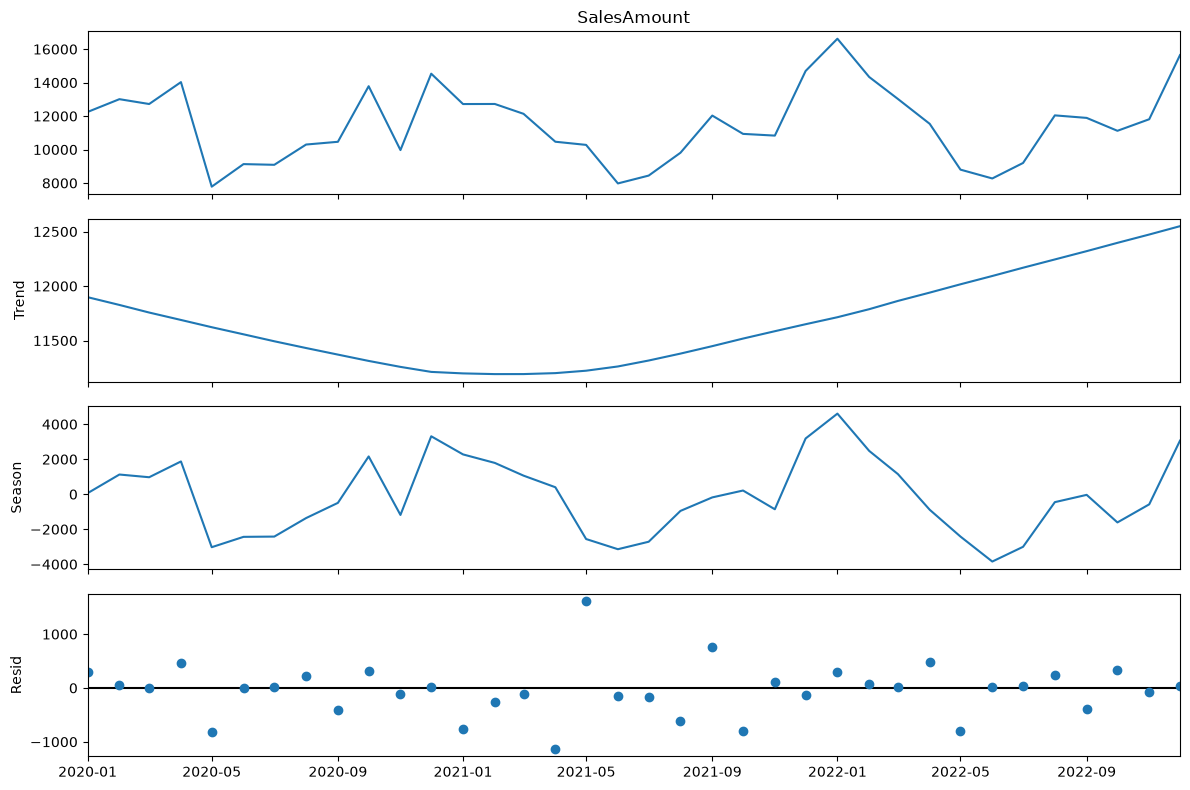

In [55]:
# stl декомпозиция
stl = STL(sales_train, period=12).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [58]:
# оценим силу сезонности и тренда
T = stl.trend
S = stl.seasonal
R = stl.resid
print("Seasonality strength:", max(0, 1 - np.var(R) / np.var(S + R)))   # сила сезонности
print("Trend strength: ", max(0, 1 - np.var(R) / np.var(T + R)))        # сила тренда

Seasonality strength: 0.9487186453420924
Trend strength:  0.4475722440435054


`Trend strength:  0.4475722440435054` - тренд незначителен \
`Seasonality strength: 0.9487186453420924` - сезонность значительна, подтверждение наблюдений выше

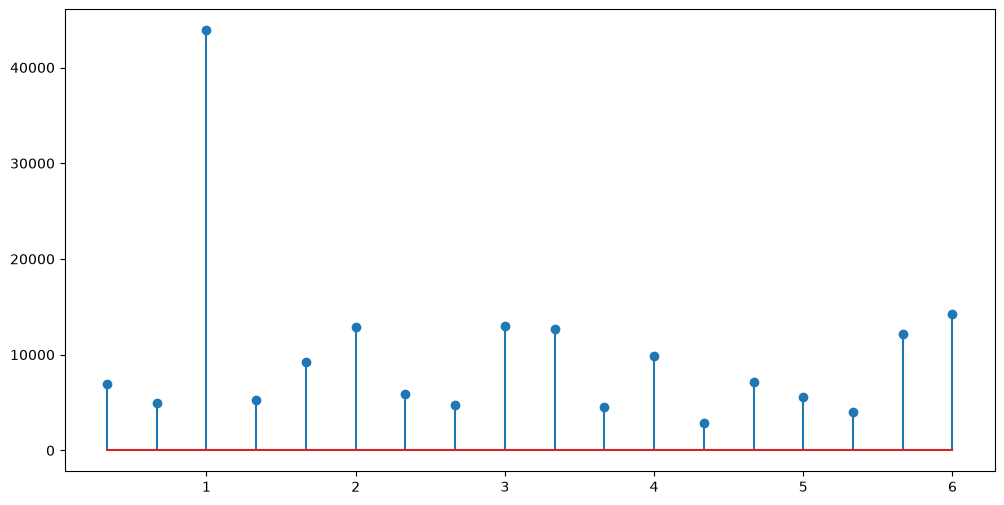

In [72]:
# FFT (rfft удобнее для действительных сигналов - возвращает только положительниые частоты)
padded = np.pad(sales_train, (0, 0))
spec = rfft(padded)[1:]                     # [1:] - убираем DC компоненту, сигнал имеет ненулевое среднее, она будет попросту мешать 
freqs = rfftfreq(len(padded), 1 / 12)[1:]   # единица времени - год, интерпретация частоты - периоды за год
mags = np.abs(spec)
plt.figure(figsize=(12, 6))
plt.stem(freqs, mags)
plt.show()

/tmp/ipykernel_7138/1720873959.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


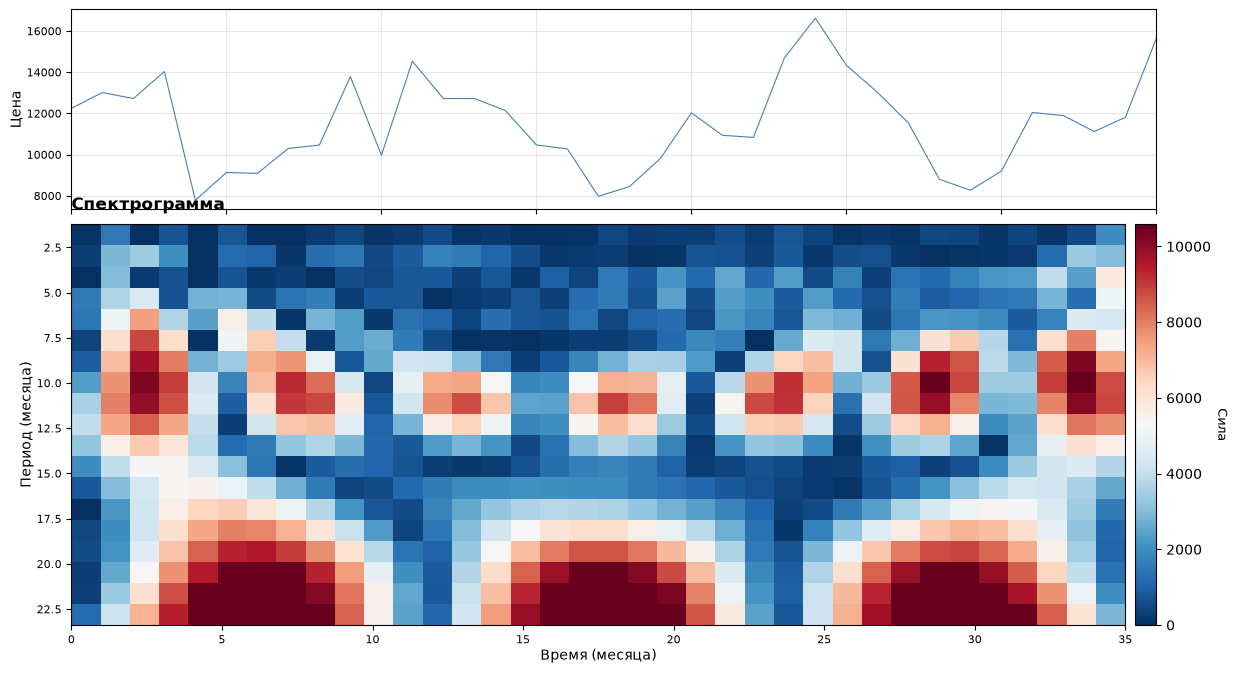

In [86]:
# wavelet
wavelet = "morl"
scales = np.arange(1, 24)
coefficients, frequencies = cwt(sales_train, scales, wavelet, sampling_period=1) # период - 1 месяц

# Подготовка спектрограммы
mask = frequencies > 0
periods = 1 / frequencies[mask]
coefficients_abs = np.abs(coefficients[mask, :])
period_mask = (periods >= 1) & (periods <= 24)
periods_plot = periods[period_mask]
coefficients_plot = coefficients_abs[period_mask, :]

# === Визуализация: Сигнал + Спектрограмма ===
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                        gridspec_kw={"height_ratios": [1, 2], "hspace": 0.05})

# 1) Исходный сигнал
t = np.arange(len(sales_train))
axs[0].plot(t, sales_train, color="steelblue", linewidth=0.8)
axs[0].set_ylabel("Цена", labelpad=2)
axs[0].grid(True, alpha=0.3)
axs[0].tick_params(labelsize=8)

# 2) Спектрограмма
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="2%", pad=0.1)

im = axs[1].imshow(coefficients_plot,
                   extent=[t.min(), t.max(), periods_plot.max(), periods_plot.min()],
                   aspect="auto", cmap="RdBu_r",
                   vmin=0, vmax=np.percentile(coefficients_plot, 95))
axs[1].set_title("Спектрограмма", fontweight="bold", loc="left", y=1.02, pad=5)
axs[1].set_ylabel("Период (месяца)", labelpad=2)
axs[1].tick_params(labelsize=8)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Сила", rotation=270, labelpad=12, fontsize=9)

axs[1].set_xlabel("Время (месяца)", labelpad=2)

plt.tight_layout(pad=2.0)
plt.show()


### Промежуточные результаты

STL очередной раз доказал наличие сезонности, также он показал отсутсвие значимого тренда. Данное наблюдение одно из необходимых условий, чтобы считать сигнал стационарным (более точно гипотеза будет проверена ниже).

При помощи Фурье и вейвлетов несложно установить, что период сезонности - около 1 года.

Можно заметить, что период сезлнности у продаж и праздничных месяцев одинаковый. Поэтому, для простоты эти данные так же можно не учитывать.

# Построение прогнозных моделей

In [97]:
sales_diff12 = np.diff(sales_train, 12) # сезонная разность, 12 было получено выше

adf_res = adfuller(sales_diff12)
print("ADF p-value (after D=1)", adf_res[1])

kpss_res = kpss(sales_diff12, regression='c')
print("KPSS p-value (after D=1):", kpss_res[1])

ADF p-value (after D=1) 7.922686336127581e-07
KPSS p-value (after D=1): 0.1


Результат - после дифференцирования ряд стационарен

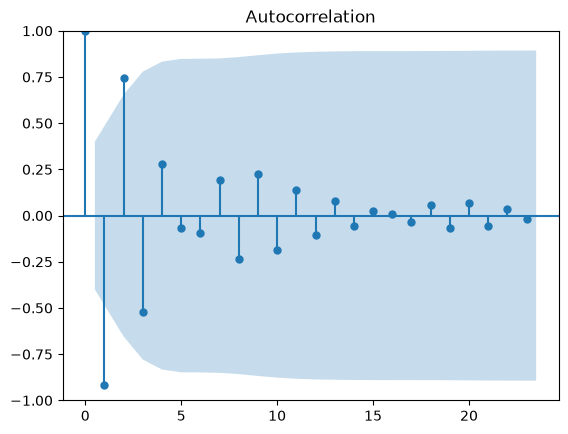

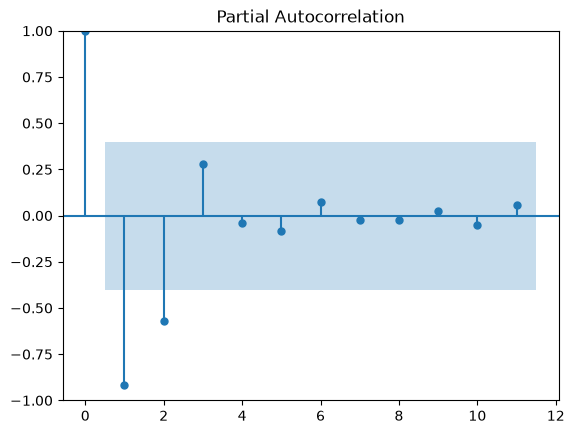

In [150]:
# построим ACF и PACF дифференцированного сигнала для определения количества AR и MA коэффициентов
plot_acf(sales_diff12, lags=23)
plot_pacf(sales_diff12, lags=11)
plt.show()

На обоих графиках лаг 2 - последний значимый:
1. p в {0,1,2}
2. q в {0,1,2}
3. P и Q кажутся нулевыми

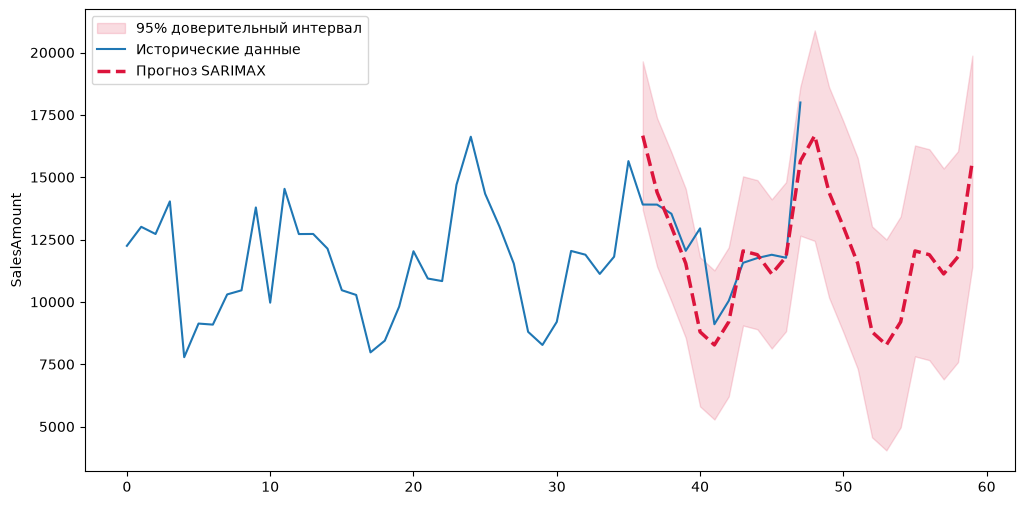

In [171]:
arima = ARIMA(sales_train, 
              order=(2, 0, 1),              # p и q из интервалов, отсутствие тренда
              seasonal_order=(0, 1, 0, 12)  # P=Q=0, сезонность с периодом 12 месяцев
             ).fit()
n = 24
full_dates = np.arange(len(sales_full))
forecast_dates = np.arange(n) + len(sales_train)
forecast_arima = arima.get_forecast(steps=24)

forecast_mean = forecast_arima.predicted_mean
conf_int = forecast_arima.conf_int(alpha=0.05)
plt.figure(figsize=(12, 6))

plt.fill_between(forecast_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="crimson", alpha=0.15, label="95% доверительный интервал")
sns.lineplot(x=full_dates, y=sales_full, label="Исторические данные")
sns.lineplot(x=forecast_dates, y=forecast_mean.values, label="Прогноз ARIMA", linewidth=2.5, color="crimson", linestyle="--")
plt.show()

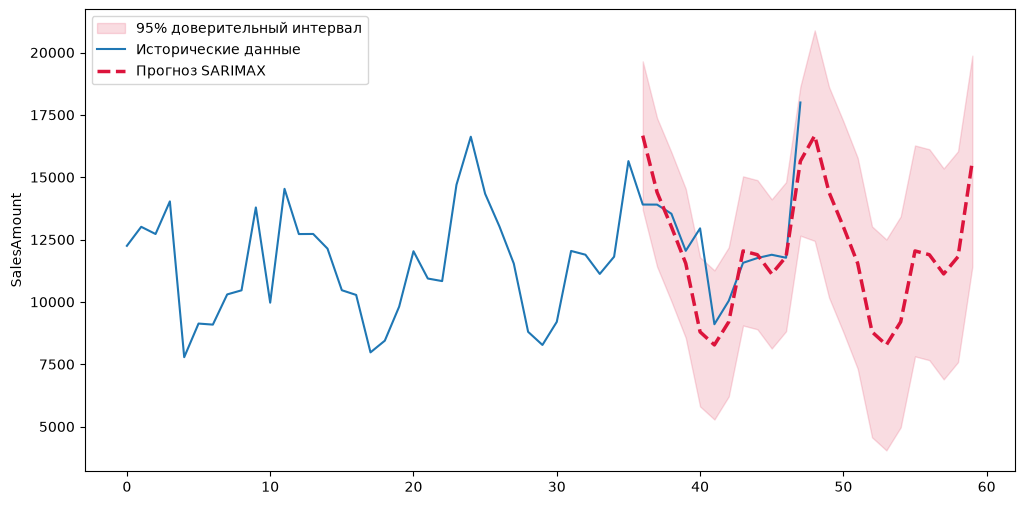

In [173]:
arima = SARIMAX(sales_train, 
                order=(2, 0, 1),              # p и q из интервалов, отсутствие тренда
                seasonal_order=(0, 1, 0, 12)  # P=Q=0, сезонность с периодом 12 месяцев
               ).fit()
n = 24
full_dates = np.arange(len(sales_full))
forecast_dates = np.arange(n) + len(sales_train)
forecast_arima = arima.get_forecast(steps=24)

forecast_mean = forecast_arima.predicted_mean
conf_int = forecast_arima.conf_int(alpha=0.05)
plt.figure(figsize=(12, 6))

plt.fill_between(forecast_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="crimson", alpha=0.15, label="95% доверительный интервал")
sns.lineplot(x=full_dates, y=sales_full, label="Исторические данные")
sns.lineplot(x=forecast_dates, y=forecast_mean.values, label="Прогноз SARIMAX", linewidth=2.5, color="crimson", linestyle="--")
plt.show()

### Промежуточный результат

С принятыми выше упрощениями модели ARIMA и SARIMAX абсолютно идентичны (нет exog). Исторические данные тестовой выборки попадают в доверительный интервал, что подтверждает адекватность принятых упрощений и корректность модели.

Т.к. модели идентичны, то дальнейший анализ будет проведён с использованием ARIMA.

## Оценка качества моделей 

## Сравнение моделей с разными гиперпараметрами

In [185]:
# grid search по гиперпараметрам в допустимых пределах
p_range = [0, 1, 2]
q_range = [0, 1, 2]
d, D, s = 0, 1, 12

grid_results = {}

# сам grid search
for p, q in product(p_range, q_range):
    order = (p, d, q)
    seasonal_order = (0, D, 0, s)
    m_arima = ARIMA(sales_train, order=order,  seasonal_order=seasonal_order,).fit()
    sales_pred = m_arima.forecast(steps=len(sales_test))
    mse_s = mean_squared_error(sales_test, sales_pred)
    r2_s = r2_score(sales_test, sales_pred)
    grid_results[(p, q)] = (mse_s, r2_s, m_arima.aic, m_arima.bic)

# генерация таблиц в MD формате
metric_names = ["MSE", "R2", "AIC", "BIC"]
for i, mname in enumerate(metric_names):
    print(f"### {mname}\n *|{" | ".join(f"q={q}" for q in q_range)}")
    print("|".join(["-"] * (len(q_range) + 1)))
    for p in p_range:
        items = [f"p={p}"]
        items += [f"{grid_results[(p, q)][i]:.3f}" for q in q_range]
        print(" | ".join(items))


### MSE
 *|q=0 | q=1 | q=2
-|-|-|-
p=0 | 2757115.250 | 2754084.651 | 2792574.272
p=1 | 2754132.756 | 2753098.656 | 2735886.147
p=2 | 2774496.045 | 2783648.587 | 2988061.521
### R2
 *|q=0 | q=1 | q=2
-|-|-|-
p=0 | 0.404 | 0.405 | 0.396
p=1 | 0.404 | 0.405 | 0.408
p=2 | 0.400 | 0.398 | 0.354
### AIC
 *|q=0 | q=1 | q=2
-|-|-|-
p=0 | 424.616 | 426.671 | 428.239
p=1 | 426.622 | 426.890 | 428.758
p=2 | 428.354 | 430.316 | 429.976
### BIC
 *|q=0 | q=1 | q=2
-|-|-|-
p=0 | 425.794 | 429.027 | 431.773
p=1 | 428.978 | 430.424 | 433.470
p=2 | 431.889 | 435.028 | 435.866


### MSE
 *|q=0 | q=1 | q=2
-|-|-|-
p=0 | 2757115.250 | 2754084.651 | 2792574.272
p=1 | 2754132.756 | 2753098.656 | 2735886.147
p=2 | 2774496.045 | 2783648.587 | 2988061.521

### R2
 *|q=0 | q=1 | q=2
-|-|-|-
p=0 | 0.404 | 0.405 | 0.396
p=1 | 0.404 | 0.405 | 0.408
p=2 | 0.400 | 0.398 | 0.354

### AIC
 *|q=0 | q=1 | q=2
-|-|-|-
p=0 | 424.616 | 426.671 | 428.239
p=1 | 426.622 | 426.890 | 428.758
p=2 | 428.354 | 430.316 | 429.976

### BIC
 *|q=0 | q=1 | q=2
-|-|-|-
p=0 | 425.794 | 429.027 | 431.773
p=1 | 428.978 | 430.424 | 433.470
p=2 | 431.889 | 435.028 | 435.866

### Промежуточный результат

Таблицы выше показывают, что оптимальными параметрами являются p=0 и q=0 - повышение числа параметров не приводит к значительному улучшению предсказаний (метрики MSE и R2), при этом согласно AIC и BIC критериям данных парметров достаточно.

Отсюда получается, что **сезонных критериев достаточно для поного описания ряда**.

## Анализ остатков модели

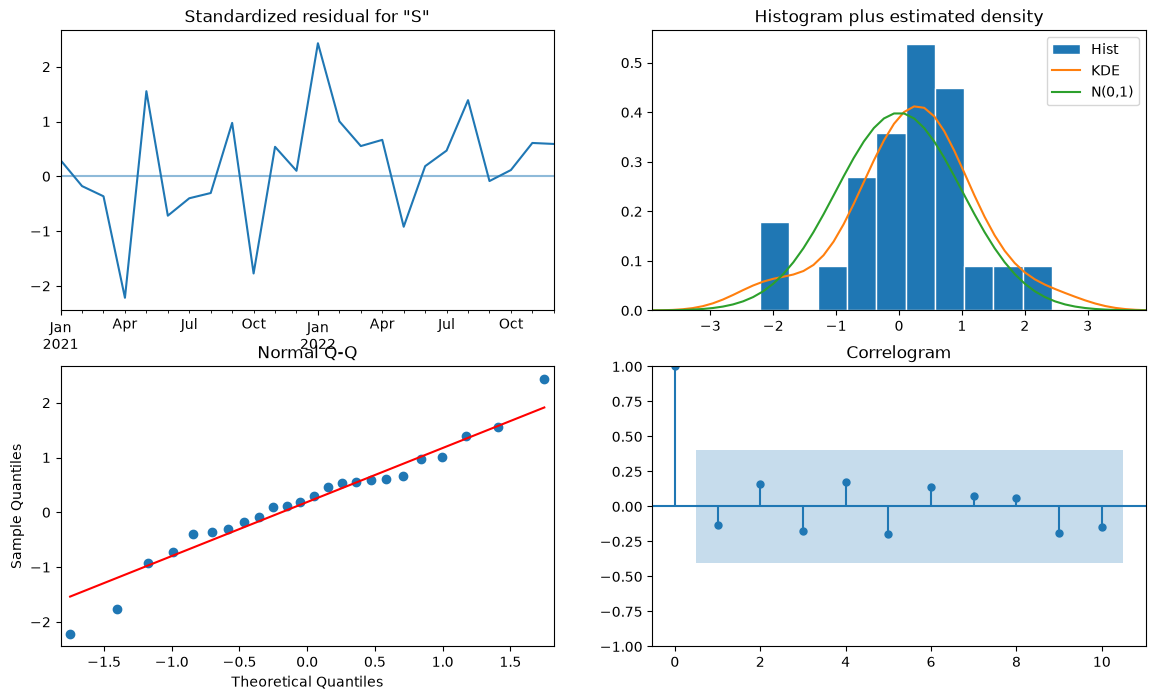

In [186]:
model = ARIMA(sales_train, order=(0, 0, 0), seasonal_order=(0, 1, 0, 12)).fit()
model.plot_diagnostics(figsize=(14, 8))
plt.show()

### Промежуточный результат

Диагностика остатков модели подтверждает её статистическую адекватность:
1. Распределение остатков близко к нормальному, Q-Q график так же подтверждает утверждение - точки лежат на диагональной линии
2. Остатки осцилирует с одинаковой дисперсией без выбросов - соблюдается гомоскедастичность
3. Отсутствует автокорреляция, что подтверждается корелограммой

# Финальный результат

В ходе работы был проанализирован предоставленный датасет и построена предсказательная модель.

Основные наблюдения и решения:
- Реклама не имеет статистически значимой корелляции с продажами, что позволяет её не учитывать
- Сезонность продаж имеет перид в 1 год
- Аналогичная сезонность и у праздников, максимальная кросскорелляция на 0 лаге, что позволяет так же не учитывать эти данные из соображений простоты
- После описанных упрощений ARIMA и SARIMAX становятся эквивалентны
- Оптимизация p/q по решётке показывает, что оптимальными параметрами является p=0 и q=0
- Полученная модель статистически адекватна, что подтверждается анализом остатков

Таким образом, используемый датасет *полностью* описывается сезонностью. В качестве оптимальной модели выбрана `ARIMA(0, 0, 0)(0, 1, 0, 12)`